# Load and inspect BCI2000 EEG data

Loads a `.dat` file from `data/eeg/raw/`, prints metadata, and plots raw traces, stimulus channel, and PSD.

`load_bci2k` reads **ChannelNames** from the BCI2000 header (e.g. PO7, Cz, AF4), sets a **standard_1020** montage, and maps **DigitalInput1** (amplifier digital input) to the MNE stim channel `STI 014`. This file does not use BCI2000's `StimulusCode` state.

Change `DATA_FILE` below to load a different run (e.g. `MET000bGridFixedS001R03.dat`).

In [6]:
%matplotlib inline
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path

PROJECT_ROOT = Path("../..").resolve()
SRC = PROJECT_ROOT / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

from eeg.inspect import print_summary
from eeg.io import load_bci2k
from eeg.viz import plot_psd, plot_raw_traces, plot_stim_channel

DATA_FILE = PROJECT_ROOT / "data/eeg/raw/MET000bGridFixedS001R02.dat"

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [7]:
raw = load_bci2k(DATA_FILE)  # DigitalInput1 -> STI 014 (default stim_state)
print_summary(raw)

Creating RawArray with float64 data, n_channels=1, n_times=209984
    Range : 0 ... 209983 =      0.000 ...   410.123 secs
Ready.
EEG channels (32): ['PO7', 'O1', 'Oz', 'O2', 'PO8', 'PO4', 'POz', 'PO3', 'P5', 'P3', 'P1', 'Pz', 'P2', 'P4', 'P6', 'CP6', 'CP2', 'CPz', 'CP1', 'CP5', 'C5', 'FC5', 'FC1', 'Cz', 'FC2', 'F4', 'FC6', 'C6', 'Fz', 'F3', 'AF3', 'AF4']
All channels (33): ['PO7', 'O1', 'Oz', 'O2', 'PO8', 'PO4', 'POz', 'PO3', 'P5', 'P3', 'P1', 'Pz', 'P2', 'P4', 'P6', 'CP6', 'CP2', 'CPz', 'CP1', 'CP5', 'C5', 'FC5', 'FC1', 'Cz', 'FC2', 'F4', 'FC6', 'C6', 'Fz', 'F3', 'AF3', 'AF4', 'STI 014']
Sampling rate: 512.0 Hz
Duration: 410.12 s
Montage: <DigMontage | 0 extras (headshape), 0 HPIs, 3 fiducials, 32 channels>
Stimulus channel: STI 014 (from DigitalInput1)
Finding events on: STI 014
104 events found on stim channel STI 014
Event IDs: [1]
DigitalInput1 rising edges: 104
Events (find_events): 104
Event counts: {1: 104}


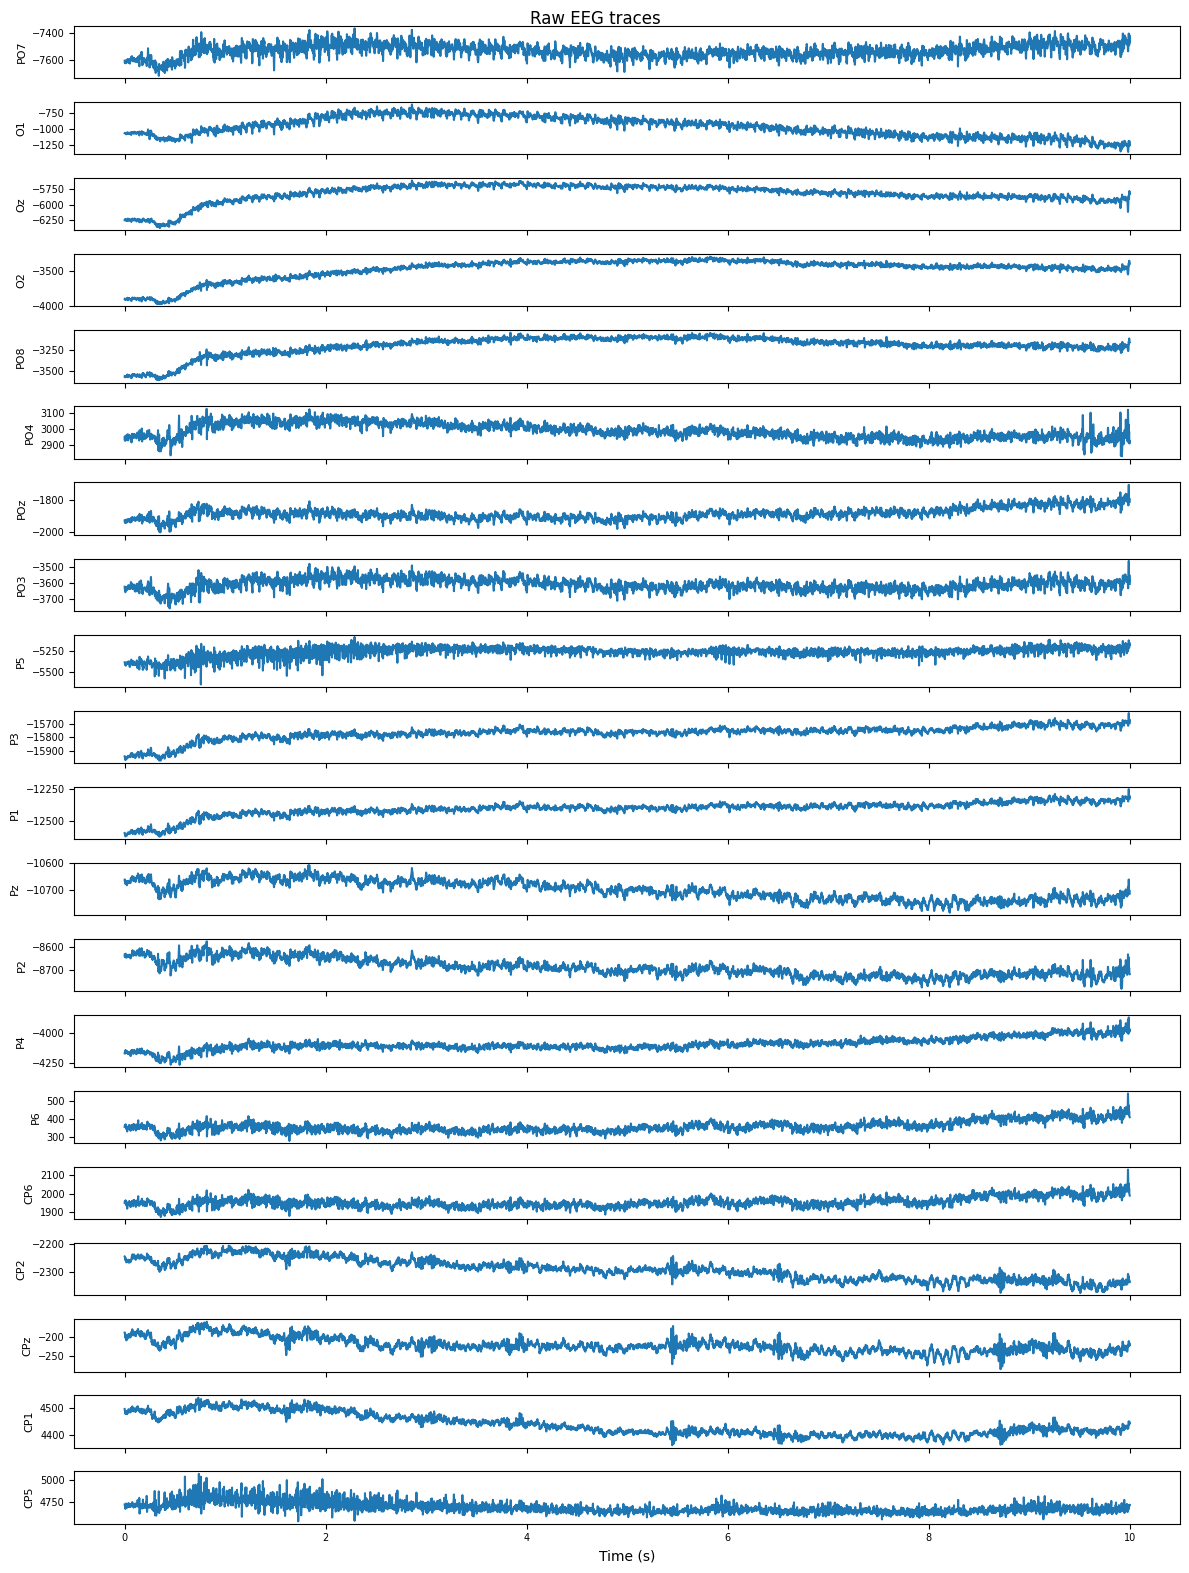

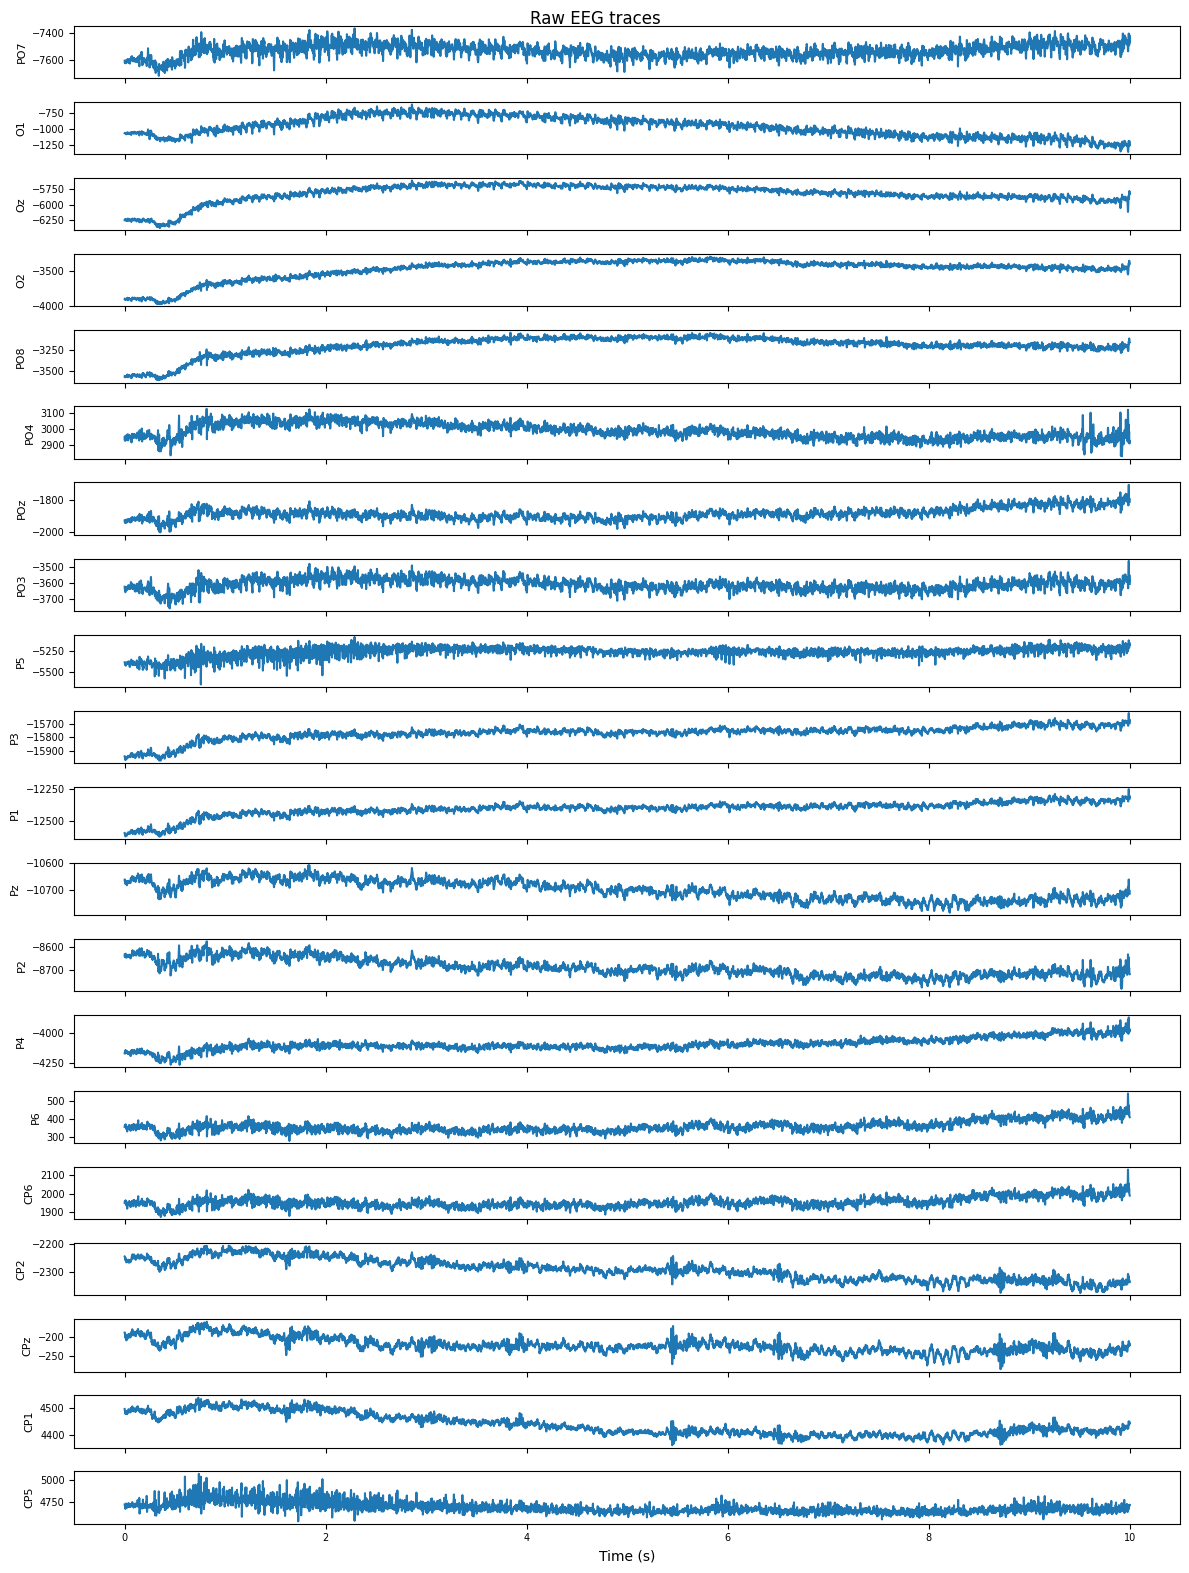

In [8]:
plot_raw_traces(raw)

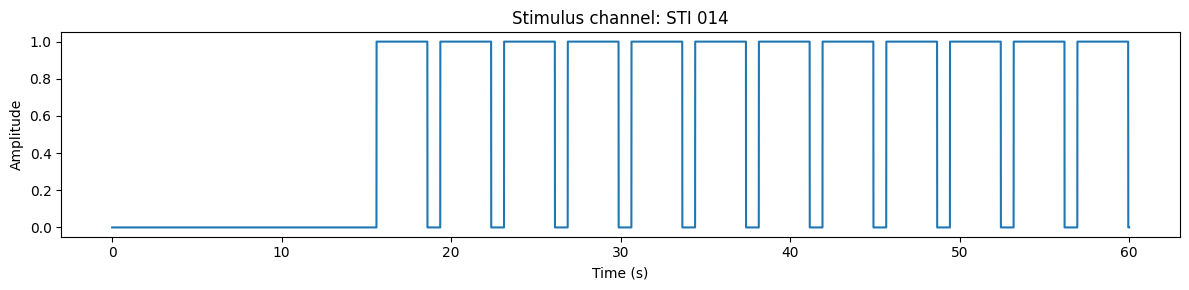

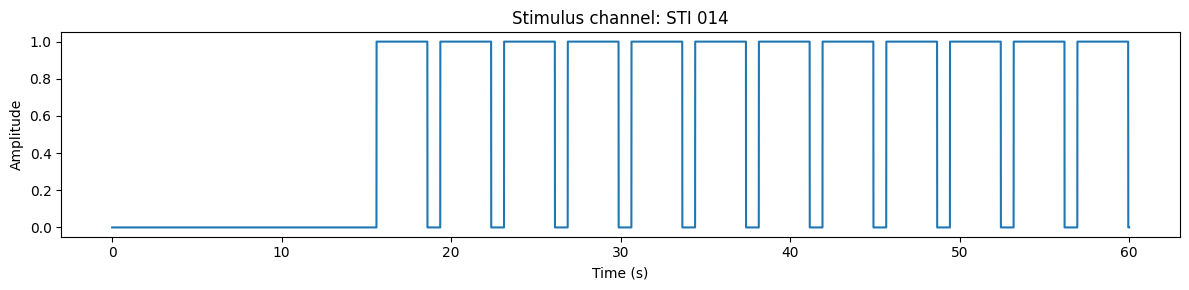

In [9]:
plot_stim_channel(raw)

Effective window size : 4.000 (s)
Plotting power spectral density (dB=True).


/home/zevaz/projects/dataAnalysisCursor/.venv/lib/python3.12/site-packages/mne/viz/utils.py:160: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


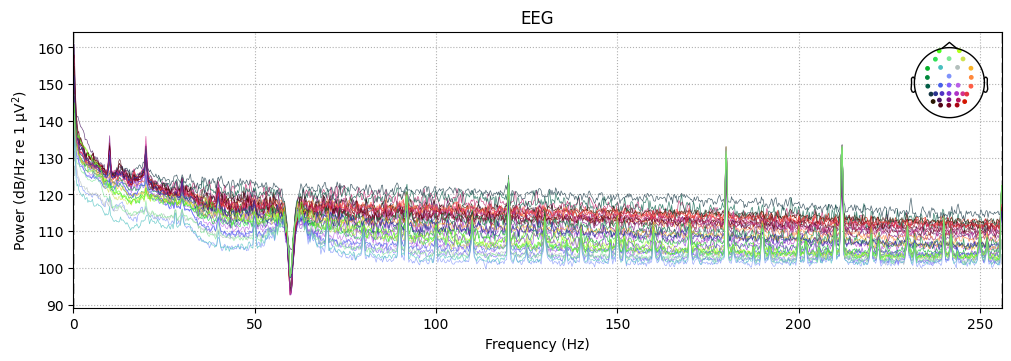

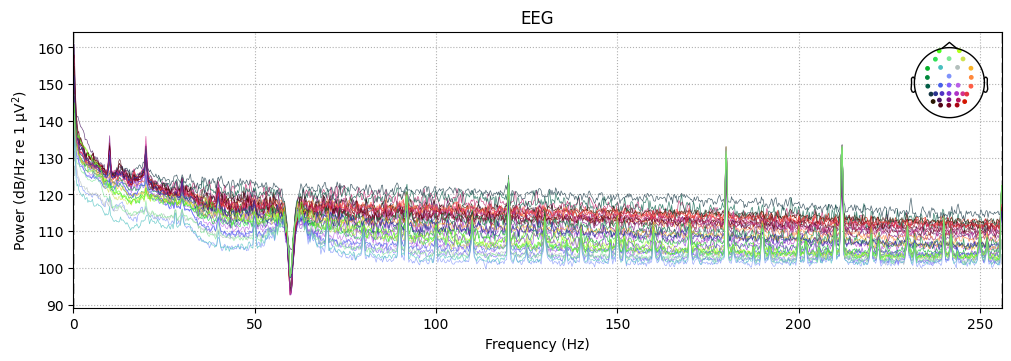

In [10]:
plot_psd(raw)